# Clustering (Agrupamiento)

El clustering es una técnica que organiza un conjunto de datos en grupos o clústeres, donde los datos dentro de cada grupo son más similares entre sí que a los datos en otros grupos. Es una forma de aprendizaje no supervisado, en la cual el objetivo es descubrir la estructura subyacente en los datos sin tener etiquetas predefinidas.

En lugar de requerir información previa sobre las categorías o grupos a los que pertenecen los datos, el clustering busca identificar patrones y agrupaciones naturales en el conjunto de datos, lo que permite explorar y comprender la organización intrínseca de los datos.

## Aplicaciones del Clustering

### 1. Reconocimiento de Patrones

El reconocimiento de patrones es una aplicación del clustering que se enfoca en identificar similitudes dentro de datos complejos, como textos o señales. En este contexto, el objetivo es descubrir patrones recurrentes o estructuras comunes que puedan ayudar a comprender mejor la información.

Ejemplos:
- En el análisis de textos, el clustering puede agrupar documentos con temas similares, facilitando la organización y búsqueda de información.
- En el análisis de señales, puede identificar patrones que correspondan a eventos específicos, ayudando en la detección de anomalías o en la clasificación de señales.


### 2. Segmentación de Clientes

En el contexto de datos estadísticos, la segmentación de clientes es un proceso fundamental en el marketing, que implica agrupar a los clientes en función de comportamientos similares. Esta técnica permite a las empresas personalizar sus estrategias de marketing para cada grupo específico.

Beneficios:
- Personalización de mensajes y ofertas según cada segmento.
- Mejora la satisfacción del cliente y aumenta la fidelidad y las ventas.

## Ejemplo NFL

En la NFL, se cree que los jugadores en posiciones defensivas como *nose tackle*, *defensive tackle* y *defensive end* son los más pesados, ya que su función principal es enfrentar y detener a los adversarios con fuerza física.

En contraste, los jugadores en posiciones como *cornerbacks*, *defensive backs* y *safeties* suelen ser más ligeros, debido a que su tarea principal es cubrir a los receptores, lo cual requiere agilidad y velocidad, en lugar de masa corporal.

A continuación se presentan algunas fotos de jugadores en diferentes posiciones para ilustrar estas diferencias.

<table>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=1jXsaKcpnMhzox8-61ev4dMu6xA8NNXdo" width="250" height="200">
      <p>Nose tackle</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1y64BWz41P8CUtzsXqCsWIvuSWsf8OAbC" width="200" height="200">
      <p>Defensive tackle</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1Arhi8BCFCa2fPFKsRS_iEg0bWn7_r6_m" width="200" height="200">
      <p>Defensive end</p>
    </td>
  </tr>
  <tr>
    <td>
      <img src="https://drive.google.com/uc?id=1ugzpcYuV_gNm1rvN7cQP4UdTC8PkZTq_" width="200" height="200">
      <p>Cornerback</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1iM9M2HQa5Kla5RVvhhWKhMTwqNbkfDIz" width="200" height="200">
      <p>Defensive back</p>
    </td>
    <td>
      <img src="https://drive.google.com/uc?id=1BnR4L35T2YfJWoEYljSLt55cYQ-xKSa3" width="200" height="200">
      <p>Safety</p>
    </td>
  </tr>
</table>




#Análisis de datos en NF
Para determinar qué tan cierta es la afirmación anterior se decidió conseguir información de jugadores de diferentes posiciones en la NFL. En la plataforma Kaggle se encuentra disponible la base de datos [NFL Statistics](https://www.kaggle.com/datasets/kendallgillies/nflstatistics/data).

Esta base de datos incluye información detallada sobre jugadores de la NFL. No obstante, para los fines de este ejercicio, se han conservado únicamente la altura y el peso de los jugadores en las posiciones especificadas.

Exploraremos el contenido del archivo $NFL\_Filtrado.csv$ con pandas.

Primero importamos las bibliotecas que serán empleadas.
* Pandas para poder leer y manipular la información del archivo en formato csv
* Matplotlib para poder mostrar las figuras que se generen
* Seaborn para generar un diagrama de dispersión.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Enlace del archivo CSV en Google Drive
ruta_csv = "/content/drive/MyDrive/Inteligencia Artificial Aplicada/Clustering/NFL_Filtrado.csv"

# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(ruta_csv)

#Imprimir la información del dataframe
print(df.head())


   Height (inches)  Weight (lbs) Position
0               77           305       DE
1               72           210       DB
2               74           190       CB
3               74           208       CB
4               72           212       FS


Observa que en efecto tiene una columna para altura, otra para peso y finalmente una que indica la posición del jugador asociado a cada muestra.

Para saber cuáles son las posiciones que se están considerando en este archivo, se puede usar la función $\textit{unique()}$ sobre la columna $\textit{Position}$.  

Al imprimir el resultado se verán las siglas: DE, DB, CB, FS, DT, NT.

In [ ]:
# Obtener una muestra de cada abreviatura en la columna "Position"
positions = df['Position'].unique()
print(positions)

['DE' 'DB' 'CB' 'FS' 'DT' 'NT']


Estas siglas corresponden a las siguientes posiciones:
* NT = Nose Tackle
* DT = Defensive Tackle
* DE = Defensive End
* CB = Cornerback
* DB = Defensive Back
* FS = Free Safety


Ahora vamos a analizar la relación entre las posiciones de los jugadores y su peso mediante un diagrama de dispersión. Para esto, primero clasificaremos las posiciones en dos grupos:
* Grupo 1: Incluye las posiciones DE, DT y NT.
* Grupo 2: Incluye todas las demás posiciones.

In [ ]:
# Definir los grupos de posiciones y sus colores
grupo1 = ['DE', 'DT', 'NT']

# Crear una nueva columna en el DataFrame para el grupo
df['Grupo'] = df['Position'].apply(lambda x: 'Grupo1' if x in grupo1 else 'Grupo2')

# Veamos los primeros cinco renglones
df.head()

,Height (inches),Weight (lbs),Position,Grupo
0,77,305,DE,Grupo1
1,72,210,DB,Grupo2
2,74,190,CB,Grupo2
3,74,208,CB,Grupo2
4,72,212,FS,Grupo2


Finalmente generamos un diagrama de dispersión para visualizar la relación entre la altura y el peso de los jugadores, diferenciados por grupos.

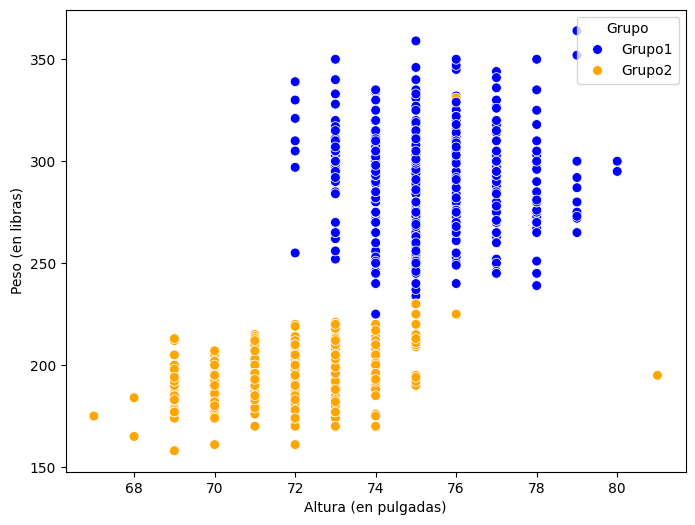

In [ ]:
# Crear el diagrama de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Height (inches)', y='Weight (lbs)', hue='Grupo', palette={'Grupo1': 'blue', 'Grupo2': 'orange'}, s=50, edgecolor='w')

# Configurar el título y las etiquetas
plt.xlabel('Altura (en pulgadas)')
plt.ylabel('Peso (en libras)')
plt.legend(title='Grupo', loc='upper right')

# Mostrar el gráfico
plt.show()

En las siguientes secciones, se describen varias técnicas comunes de clustering, incluyendo k-medias, algoritmos de agrupamiento jerárquico, modelos de mezcla gaussiana y DBSCAN.

Utilizaremos los datos del archivo $NFL\_Filtrado$ para ilustrar el rendimiento de cada técnica.

Este ejemplo es relativamente sencillo y presenta grupos claramente definidos, lo que hace que el uso de algoritmos de clustering sea innecesario en un contexto práctico, resulta ideal para fines académicos.

Los clústeres son conocidos y fácilmente visibles, lo que nos permitirá evaluar de manera efectiva los resultados obtenidos con cada técnica.